# Nilearn atlas minimal demo

Use nilearn built-in atlas (AAL) + `draw_brain.py` functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets

from draw_brain import draw_connectome, draw_atlas_roi, get_coords

In [2]:
# 1) Load nilearn built-in nifti atlas (AAL)
atlas = datasets.fetch_atlas_aal(version="SPM12")
atlas_img = atlas.maps
label_ids = np.asarray(atlas.indices, dtype=int)
labels = np.asarray(atlas.labels)

# Keep a small subset for minimal, fast demo
n_roi = 20
sel_ids = label_ids[:n_roi]
sel_labels = labels[:n_roi]
coords = get_coords(atlas_img, label_ids=sel_ids)

print("n_roi =", n_roi)
print("first 5 labels =", sel_labels[:5])

C:\Users\kxwang\AppData\Local\Temp\ipykernel_5424\776988003.py:2: DeprecationWarning: Starting in version 0.13, the default fetched mask will beAAL 3v2 instead.
  atlas = datasets.fetch_atlas_aal(version="SPM12")


[fetch_atlas_aal] Dataset found in C:\Users\kxwang\nilearn_data\aal_SPM12
n_roi = 20
first 5 labels = ['Background' 'Precentral_L' 'Precentral_R' 'Frontal_Sup_L'
 'Frontal_Sup_R']


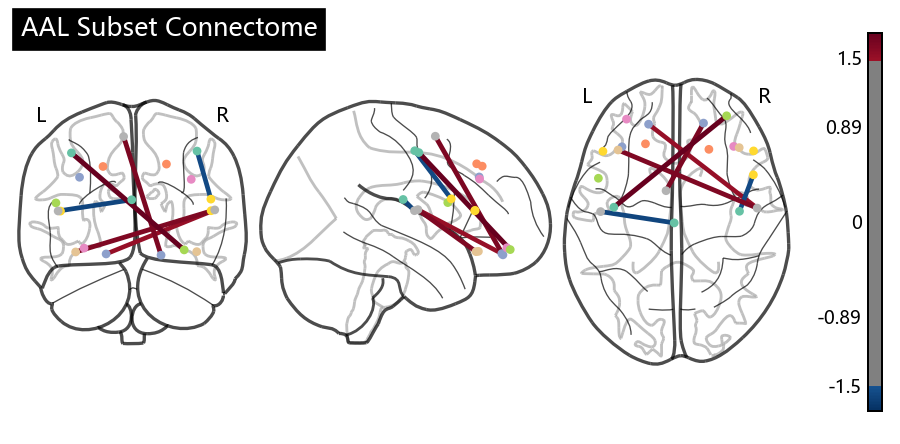

In [3]:
# 2) Minimal draw_connectome example
rng = np.random.default_rng(42)
adj = rng.normal(size=(n_roi, n_roi))
adj = (adj + adj.T) / 2.0
np.fill_diagonal(adj, 0.0)

display_conn = draw_connectome(
    adjacency_matrix=adj,
    coords=coords,
    edge_threshold="97%",
    title="AAL Subset Connectome",
    save_dir="pics",
    filename="demo_connectome_aal.png",
)
plt.show()

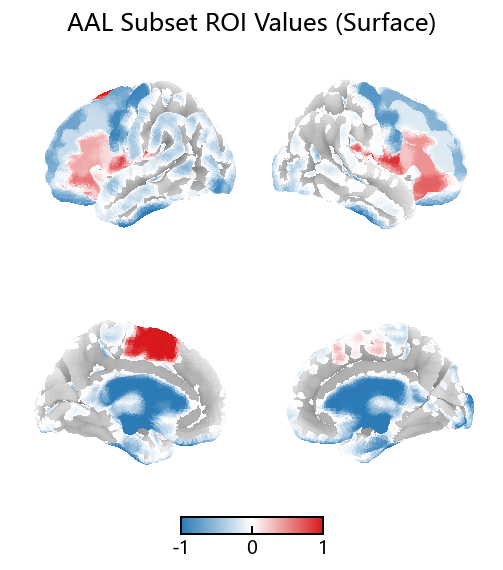

In [7]:
# 3) Minimal draw_atlas_roi example (ROI values -> cortical distribution)
# Input shape is (num_roi, 1) as requested
roi_values = np.linspace(-1.0, 1.0, n_roi).reshape(-1, 1)
roi_values.shape    #(n_rois,1)

value_img, display_roi = draw_atlas_roi(
    roi_values=roi_values,
    atlas_img=atlas_img,
    label_ids=sel_ids,
    view="surf",
    threshold=1e-8,
    title="AAL Subset ROI Values (Surface)",
    save_dir="pics",
    filename="demo_atlas_roi_aal_surf.png",
)
plt.show()